**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v3 =  Analysis 2 (filtered GCC data: ) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/24/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/24/2025
* Finished Iteration on -06/24/2025-

In [33]:
# Run once for pip installs and upgrades
#%pip install --upgrade pip


In [34]:
# Import and load libs and packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
from rapidfuzz import process, fuzz


In [35]:
# Read Files and load data
ca_personnel = pd.read_excel("city_filtered_test_data.xlsx")
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_-3971126187329447856/BOE_CityCounty.shp")

In [36]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [37]:
# Cleaning function
def clean_name(name):
    name = str(name).strip().lower()
    return name.title() if name else ''

# Clean columns for joining
ca_personnel['clean_city_name'] = ca_personnel['EmployerName'].apply(clean_name)
ca_personnel['clean_county_name'] = ca_personnel['EmployerCounty'].apply(clean_name)


In [38]:
# Filters: Comment out if not needed

# Specify the city to exclude
excluded_city = "Los Angeles"
# Specify the county to exclude
excluded_county = "Los Angeles"


In [39]:
# City aggregates
agg_city_counts = ca_personnel.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_city_counts_filtered = (
    ca_personnel[ca_personnel['clean_city_name'] != excluded_city]
    .groupby('clean_city_name')
    .size().reset_index(name='personnel_count_city')
)

# County aggregates
agg_county_counts = ca_personnel.groupby('clean_county_name').size().reset_index(name='personnel_count_county')
agg_county_counts_filtered = (
    ca_personnel[ca_personnel['clean_county_name'] != excluded_county]
    .groupby('clean_county_name')
    .size().reset_index(name='personnel_count_county')
)

# Check the aggregated personnel count for cities and counties
#agg_city_counts
#agg_city_counts_filtered
#agg_county_counts
#agg_county_counts_filtered


In [40]:
# City maps (full + filtered)
geo_city = ca_geo_df.copy()
geo_city['clean_name'] = geo_city['CITY'].apply(clean_name)
geo_city = geo_city.merge(agg_city_counts, left_on='clean_name', right_on='clean_city_name', how='left')
geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)

geo_city_filtered = ca_geo_df.copy()
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(clean_name)
geo_city_filtered = geo_city_filtered.merge(agg_city_counts_filtered, left_on='clean_name', right_on='clean_city_name', how='left')
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)

# Load actual county boundaries shapefile
county_geo = gpd.read_file(
    "California_County_Boundaries_and_Identifiers_Blue_Version_view_2716745428963682036/California_County_Boundaries_and_Identifiers.shp"
)

# Print column names to verify correct county name column
print("County Geo Columns:", county_geo.columns)

# Checks for geomaps
#geo_city
#geo_city_filtered
#geo_county
#geo_county_filtered

County Geo Columns: Index(['CDTFA_COUN', 'CDTFA_COPR', 'CENSUS_PLA', 'CENSUS_GEO', 'CENSUS_P_1',
       'GNIS_PLACE', 'GNIS_ID', 'CDT_COUNTY', 'PRIMARY_DO', 'CENSUS_POP',
       'CDT_NAME_S', 'OFFSHORE', 'AREA_SQMI', 'GlobalID', 'geometry'],
      dtype='object')


In [41]:
# Clean and standardize county name for joining
county_geo['clean_name'] = county_geo['CDT_NAME_S'].apply(clean_name)

# Merge with aggregated personnel counts
geo_county = county_geo.merge(
    agg_county_counts,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)

# Merge with filtered personnel counts (excluding Los Angeles)
geo_county_filtered = county_geo.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)


In [42]:
# Defining plotting function

def plot_personnel_map(gdf, column, title, cmap='YlGnBu'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        legend_kwds={'label': title, 'shrink': 0.5},
        ax=ax
    )
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


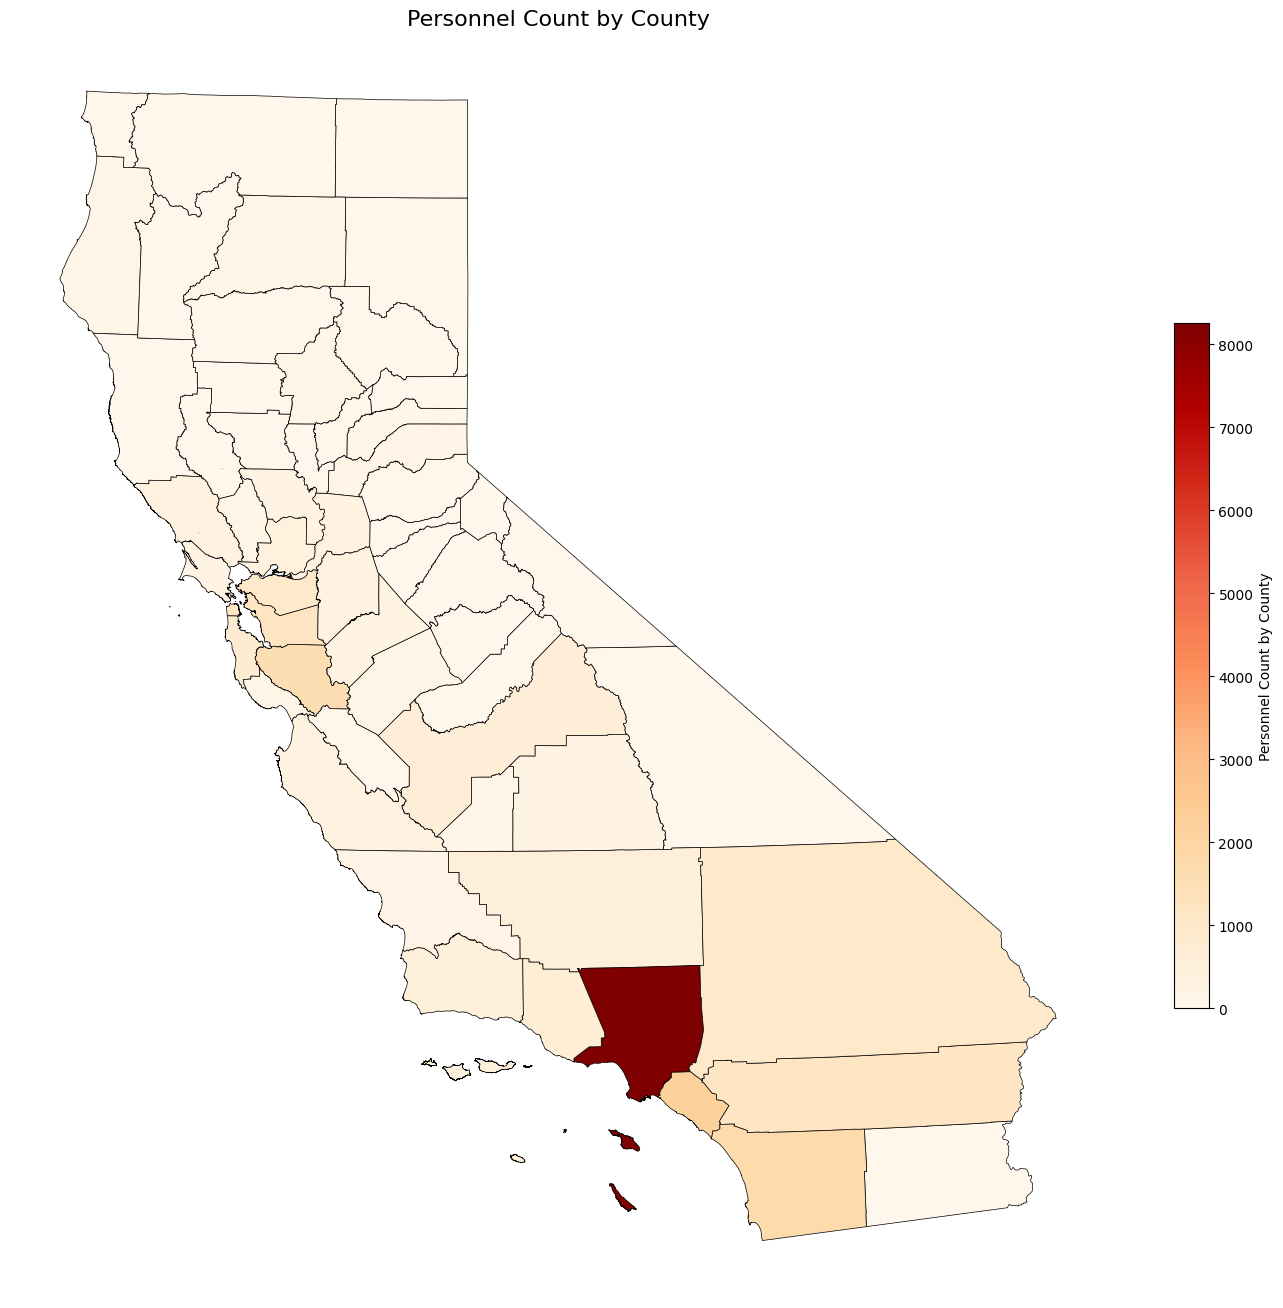

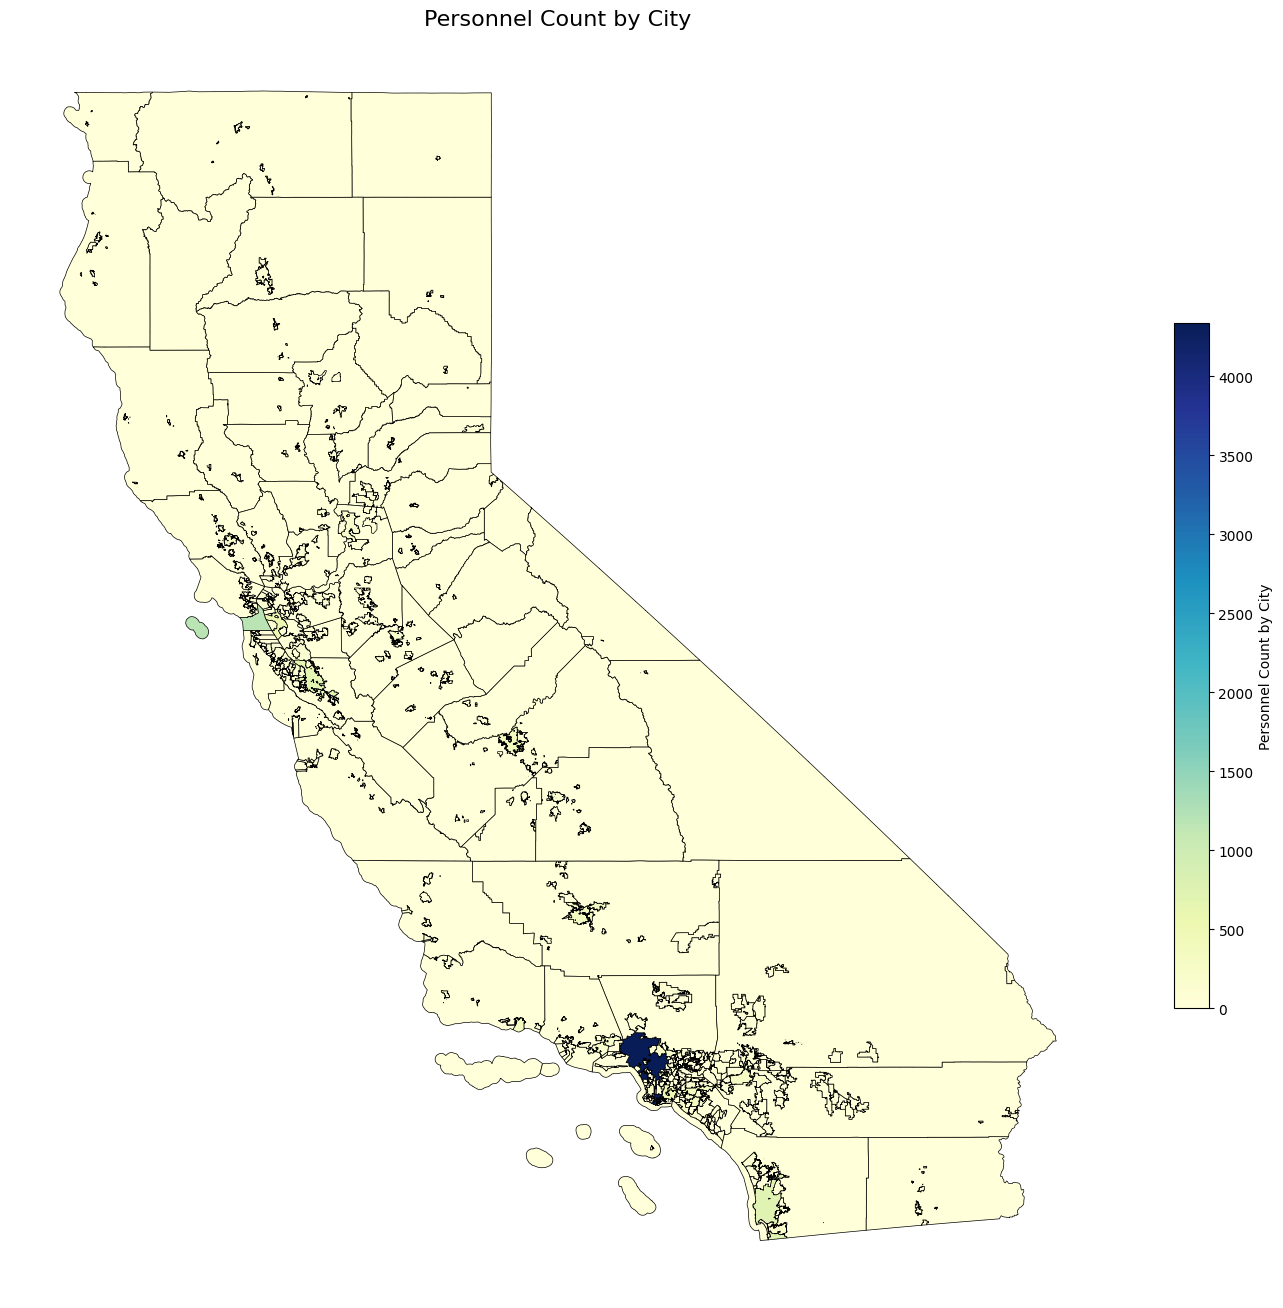

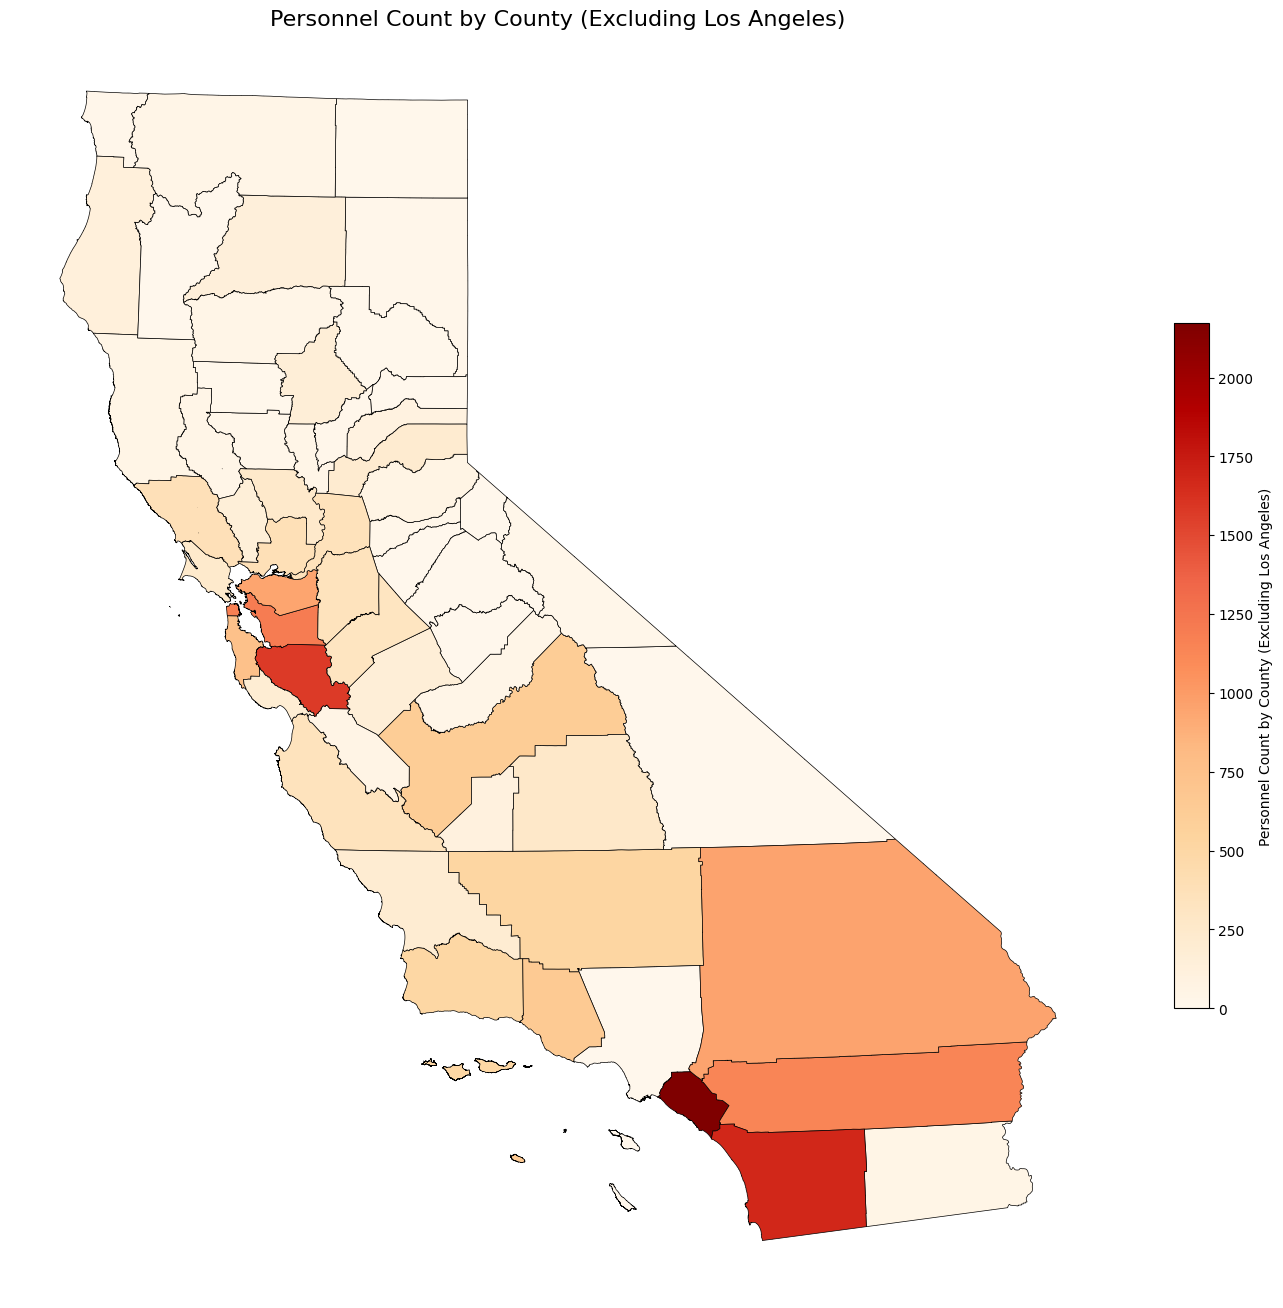

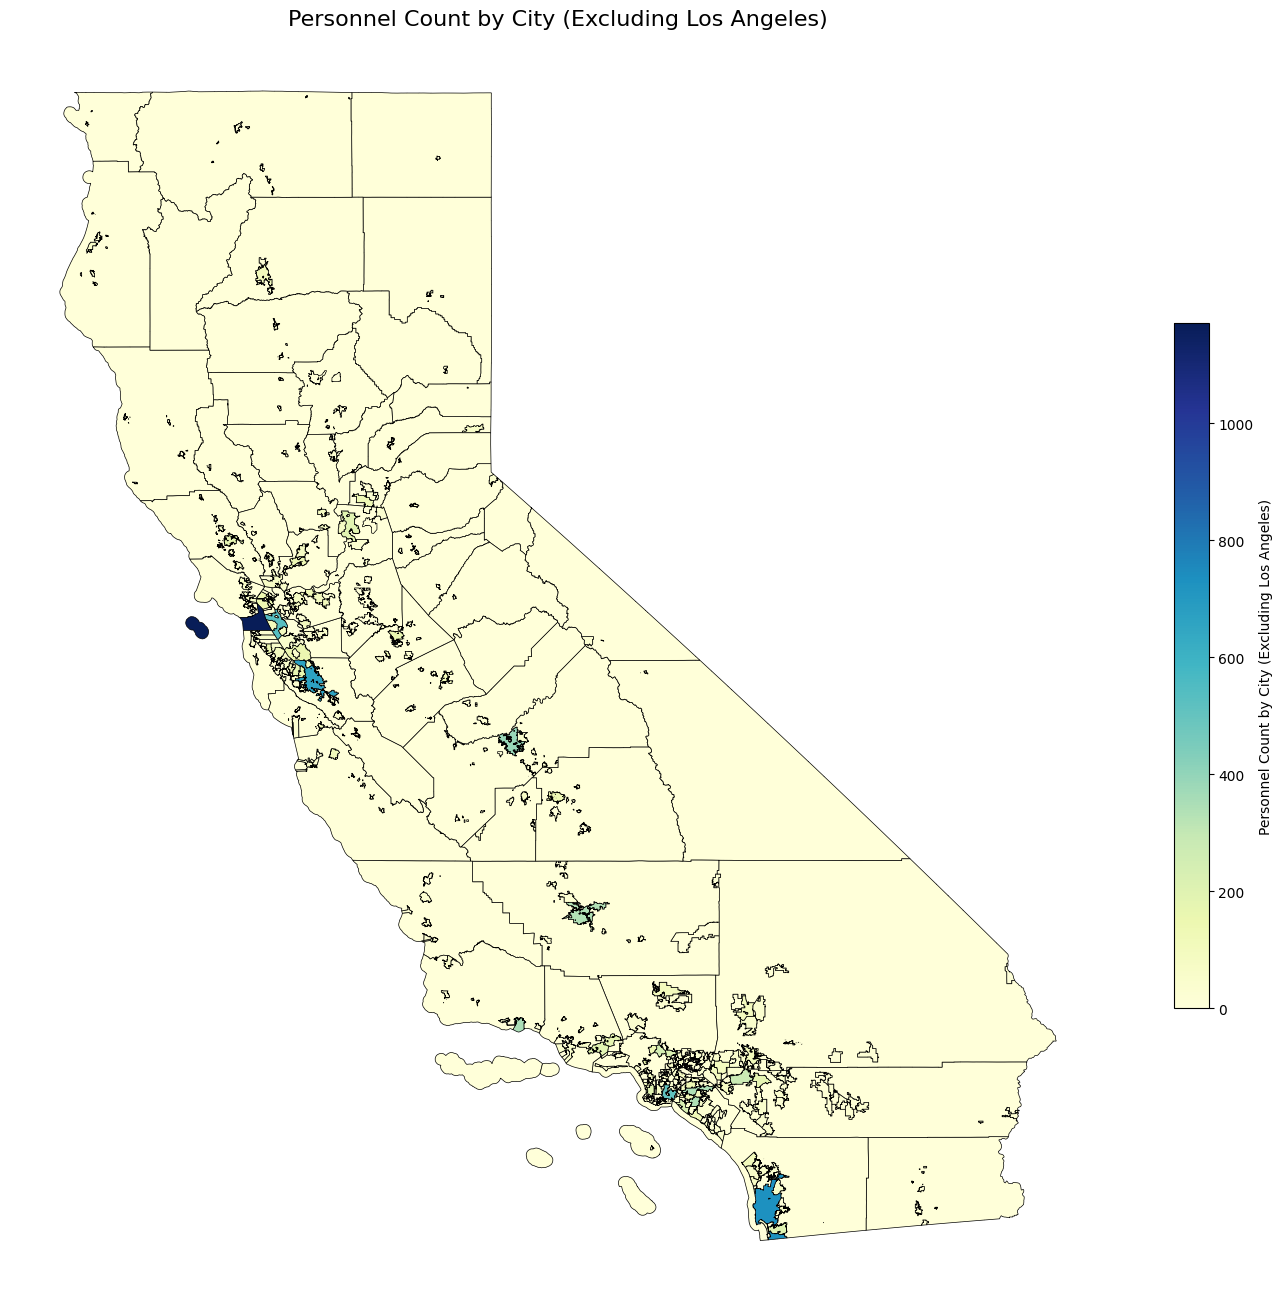

In [43]:
# Plot all maps

# County - All
plot_personnel_map(
    geo_county,
    column='personnel_count_county',
    title='Personnel Count by County',
    cmap='OrRd'
)

# City - All
plot_personnel_map(
    geo_city,
    column='personnel_count_city',
    title='Personnel Count by City',
    cmap='YlGnBu'
)

# County - Excluding Los Angeles
plot_personnel_map(
    geo_county_filtered,
    column='personnel_count_county',
    title='Personnel Count by County (Excluding Los Angeles)',
    cmap='OrRd'
)

# City - Excluding Los Angeles
plot_personnel_map(
    geo_city_filtered,
    column='personnel_count_city',
    title='Personnel Count by City (Excluding Los Angeles)',
    cmap='YlGnBu'
)
